In [1]:
import os
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import numpy.random as nr
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import scipy
import pickle

cur_dir = os.getcwd()
path = Path(cur_dir)
sys.path.insert(0, str(path.parent.absolute()))


#from src.nre.safe_routing import*
from src.nre.preprocess import preprocess_df
from src.nre.network_connectivity import ConnectivityUnit
from src.nre.safe_routing import sample_erdos_renyi_graph, compare_topologies_simple_safe_routing, get_safe_routing_perf_stats

# Generate Network and Risks

In [2]:
import importlib, src, src.nre.safe_routing

importlib.reload(src.nre.safe_routing)
from src.nre.safe_routing import *

In [3]:
import importlib, src, src.nre.network_plotting

importlib.reload(src.nre.network_plotting)
from src.nre.network_plotting import *

## Erdos Renyi

In [212]:
seed = 7342 # 7342
n = 30 # 30 
c = 1.2 # 1.2
# p = c * np.log(n) / n
g = sample_erdos_renyi_graph(n, c)

entity_names = list(g.nodes)
n = len(g)

## Preferential Attachment

In [202]:
seed = 7342 # 7342
n = 30 # 30 
c = 1.2 # 1.2
p_er = c * np.log(n) / n
m = int(n * p_er)

g = sample_barabasi_albert_graph(n, c, seed=seed)
entity_names = list(g.nodes)
n = len(g)

## Small World

In [289]:
seed = 7342 # 7342
n = 30 # 30 
c = 1.2 # 1.2
p_rewire = 0.5


g = sample_watts_strogatz_graph(n, c, p_rewire)
entity_names = list(g.nodes)
n = len(g)


In [290]:
len(entity_names), len(g.nodes)

(30, 30)

### Risk Distribution from Topology

array([0.03750463, 0.10350627, 0.06095585, 0.07971626, 0.1500775 ,
       0.1385316 , 0.22779692, 0.13167974, 0.14565022, 0.06664615,
       0.12396698, 0.16828404, 0.22391071, 0.11474287, 0.2335464 ,
       0.17202437, 0.26368086, 0.25711933, 0.34350324, 0.28725101,
       0.28882167, 0.18283585, 0.17559611, 0.18551751, 0.19393638,
       0.12483931, 0.13818388, 0.18488938, 0.10228711, 0.12207432])

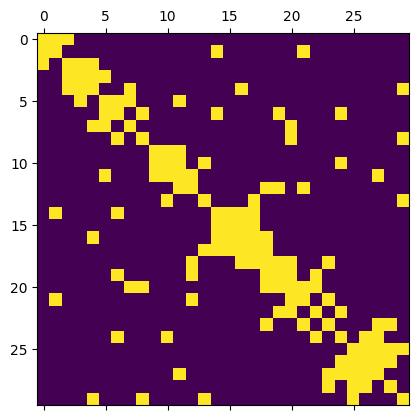

In [291]:
mat_f = nx.to_numpy_array(g, nodelist=entity_names) + np.eye(len(g))
plt.matshow(mat_f)

eig_vals, eig_vecs = np.linalg.eig(mat_f)
eig_vals
ind = np.argsort(eig_vals)
risk_mean = np.abs(eig_vecs[:, ind[-1]]) # Eigenvector with biggest eigenvalue (guaranteed to be all same sign)
risk_mean

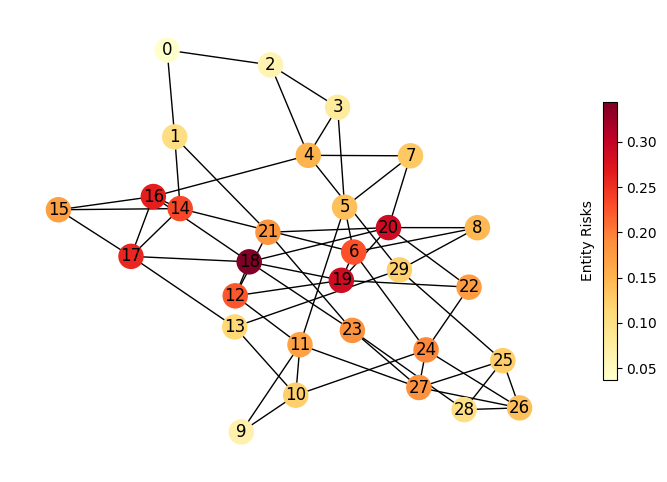

In [292]:
fig, ax = draw_spring_layout_with_risks(g, risk_mean, seed=seed**2, with_labels=True)

In [293]:
source, destination = 1, 5 #16, 46
print(source, destination)
d = nx.shortest_path_length(g, source, destination)
print(d)
len(list(nx.all_simple_paths(g, source, destination, cutoff=3.5*d)))

1 5
3


5088

Text(0.5, 9.444444444444438, 'Degree')

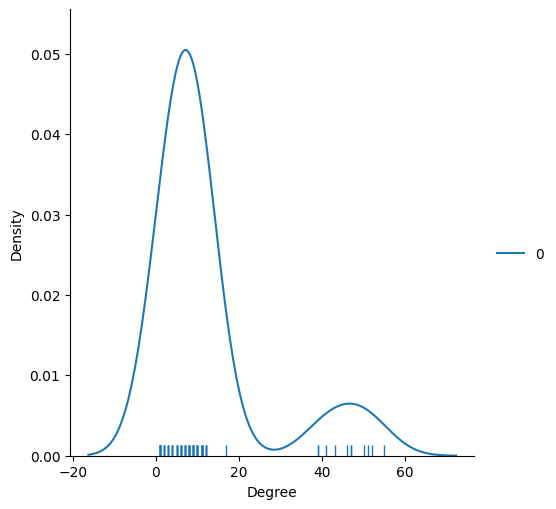

In [311]:
fg = sns.displot( dict(g.degree()).values(), kind='kde', rug=True)
plt.xlabel('Degree')

C:\Users\bayer\AppData\Local\Temp\ipykernel_5124\3681958061.py:6: RuntimeWarning: divide by zero encountered in log
  plt.plot(list(map(np.log, x)), list(map(np.log, y)))


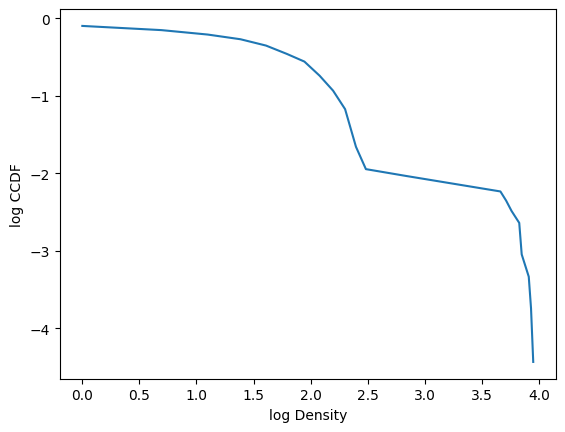

In [312]:
res = scipy.stats.ecdf(list(dict(g.degree()).values()))
x = res.cdf.quantiles
y = 1 - res.cdf.probabilities

plt.subplots()
plt.plot(list(map(np.log, x)), list(map(np.log, y)))
plt.ylabel('log CCDF')
plt.xlabel('log Density')
plt.show()

## Network from CIC-IDS

In [296]:
file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Tuesday-WorkingHours.pcap_ISCX.csv' 
df_cic = pd.read_csv(file_addr, header=0, encoding='cp1252')
df = preprocess_df(df_cic, date_col=' Timestamp')



In [297]:
with open(r'saves\victim_net.pickle', 'rb') as handle:
   entity_names = pickle.load(handle) 

In [306]:
with open(r'saves\connected_84.pickle', 'rb') as handle:
   entity_names = pickle.load(handle) 

In [307]:
g = communication_graph_from_df(df, entity_names, keep_outsiders=False)
entity_names = list(g.nodes)
len(g), len(entity_names)

(84, 84)

In [308]:
len(entity_names), len(g)

(84, 84)

In [309]:
from src.nre.kalman_network_tools import get_risk_mat_from_df

risk_mat, labels, labels_count, _, _, all_cov = get_risk_mat_from_df(df, entity_names=entity_names, t_graph=90, sync_window_size=1.2,
                                                                    return_cov=True)
risk_mean, risk_cov = risk_mat[-1,:], all_cov[-1]

with open(r'saves\risks_84.pickle', 'wb') as handle: # sample_nodes.pickle
    pickle.dump((risk_mean, risk_cov), handle, protocol=pickle.HIGHEST_PROTOCOL)


1
Current time and samples shape:  2017-04-07 01:02:00 (75, 84)
2
Current time and samples shape:  2017-04-07 01:04:00 (75, 84)
3
Current time and samples shape:  2017-04-07 01:06:00 (75, 84)
4
Current time and samples shape:  2017-04-07 01:08:00 (75, 84)
5
Current time and samples shape:  2017-04-07 01:10:00 (75, 84)
6
Current time and samples shape:  2017-04-07 01:12:00 (75, 84)
7
Current time and samples shape:  2017-04-07 01:14:00 (75, 84)
8
Current time and samples shape:  2017-04-07 01:16:00 (75, 84)
9
Current time and samples shape:  2017-04-07 01:18:00 (75, 84)
10
Current time and samples shape:  2017-04-07 01:20:00 (75, 84)
11
Current time and samples shape:  2017-04-07 01:22:00 (75, 84)
12
Current time and samples shape:  2017-04-07 01:24:00 (75, 84)
13
Current time and samples shape:  2017-04-07 01:26:00 (75, 84)
14
Current time and samples shape:  2017-04-07 01:28:00 (75, 84)
15
Current time and samples shape:  2017-04-07 01:30:00 (75, 84)
16
Current time and samples shape:

In [301]:
with open(r'saves\risks_13.pickle', 'rb') as handle:
    risk_mean, risk_cov = pickle.load(handle) 

In [ ]:
with open(r'saves\risks_84.pickle', 'rb') as handle:
    risk_mean, risk_cov = pickle.load(handle) 

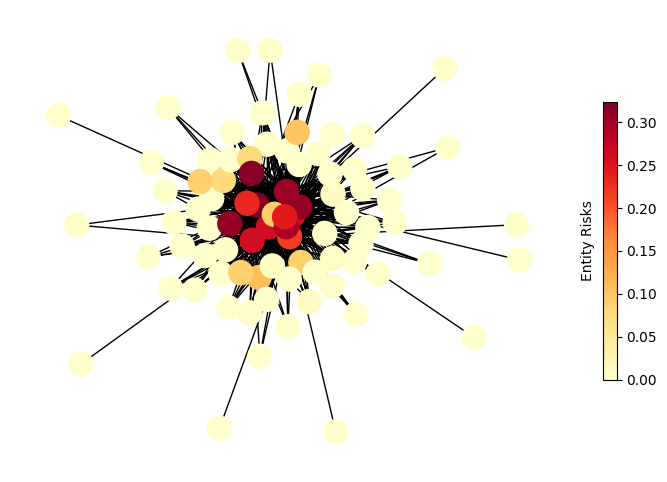

In [310]:
fig, ax = draw_spring_layout_with_risks(g, risk_mean, seed=seed**2)

In [ ]:
g = communication_graph_from_df(df.iloc[:,:], entity_names, keep_outsiders=False)
g.remove_node('192.168.10.3')

# Safe Routing

In [16]:
#source, destination = entity_names[-13], entity_names[-5]

entity_risks = {node:risk for node, risk in zip(g.nodes, risk_mean)}

minmax_paths = {node:[source] for node in g.nodes}
risk_distances = safest_path(g, source, entity_risks, path=minmax_paths)


C:\Users\bayer\PycharmProjects\NRE\src\nre\safe_routing.py:109: UserWarning: Multi-safest-paths are not added to variable path!
  warnings.warn('Multi-safest-paths are not added to variable path!')


In [17]:
minmax_paths

{0: [1, 29, 14, 0],
 1: [1],
 2: [1, 2],
 3: [1, 29, 14, 19, 17, 3],
 4: [1, 29, 14, 0, 27, 4],
 5: [1, 29, 24, 11, 5],
 6: [1, 29, 13, 26, 6],
 7: [1, 29, 14, 19, 7],
 8: [1, 16, 22, 18, 8],
 9: [1, 29, 24, 9],
 10: [1, 29, 24, 9, 10],
 11: [1, 29, 24, 11],
 13: [1, 29, 13],
 14: [1, 29, 14],
 15: [1, 29, 13, 15],
 16: [1, 16],
 17: [1, 29, 14, 19, 17],
 18: [1, 16, 22, 18],
 19: [1, 29, 14, 19],
 20: [1, 29, 14, 0, 27, 20],
 21: [1, 16, 21],
 22: [1, 16, 22],
 23: [1, 29, 24, 9, 23],
 24: [1, 29, 24],
 25: [1, 25],
 26: [1, 29, 13, 26],
 27: [1, 29, 14, 0, 27],
 28: [1, 29, 14, 0, 27, 28],
 29: [1, 29]}

## Plots

In [76]:
import importlib, src, src.nre.network_plotting

importlib.reload(src.nre.network_plotting)
from src.nre.network_plotting import*

In [19]:
np.unique(list(risk_distances.values()))

array([0.23967896, 0.26061676, 0.26977157, 0.28246005, 0.28896514,
       0.34003545, 0.4013529 ])

C:\Users\bayer\PycharmProjects\NRE\venv2\lib\site-packages\networkx\drawing\nx_pylab.py:450: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


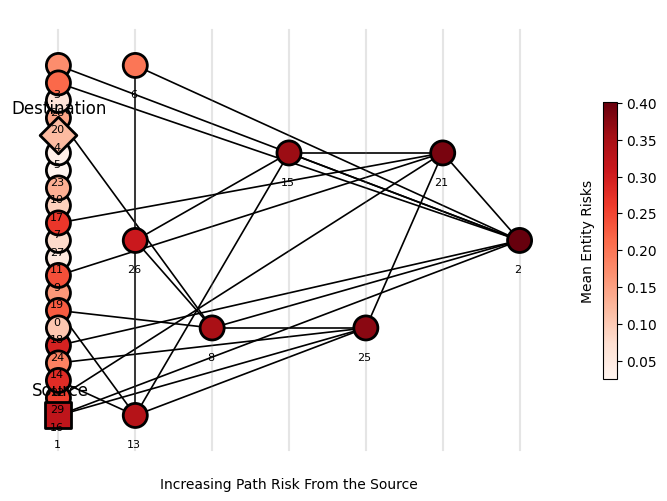

In [20]:
cmap = plt.cm.Reds
fig = cartesian_dist_plot(g, risk_distances, entity_risks, title='', show_names=True, label_size = 8, cmap=cmap,
                          destination=destination, discrete_color=True)#, paths_highlight=paths_highlight )

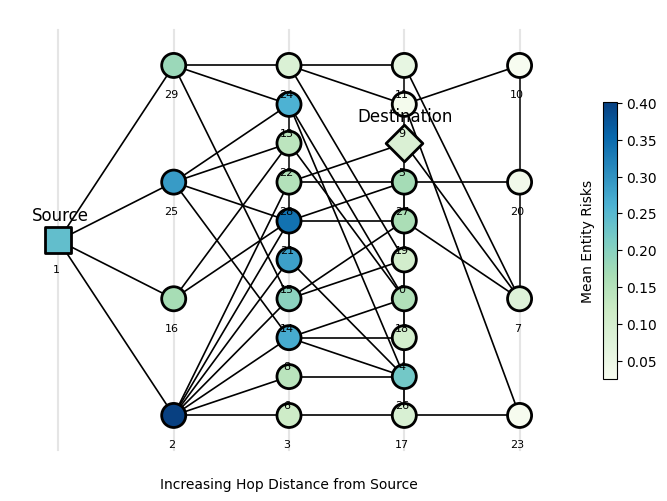

In [21]:
cmap = plt.cm.GnBu
hop_dists = nx.shortest_path_length(g, source=source)
fig = cartesian_dist_plot(g, hop_dists, entity_risks, cmap=cmap, #cbar_label='Hop Distances',
                          x_label='Increasing Hop Distance from Source',
                          show_names=True, label_size = 8, destination=destination, discrete_color=False)

In [22]:
hop_dists

{1: 0,
 2: 1,
 16: 1,
 25: 1,
 29: 1,
 3: 2,
 6: 2,
 8: 2,
 14: 2,
 15: 2,
 21: 2,
 28: 2,
 22: 2,
 13: 2,
 24: 2,
 17: 3,
 26: 3,
 4: 3,
 18: 3,
 0: 3,
 19: 3,
 27: 3,
 5: 3,
 9: 3,
 11: 3,
 23: 4,
 7: 4,
 20: 4,
 10: 4}

In [23]:
print(source, destination)
d = nx.shortest_path_length(g, source, destination)
max_hops = 2.5*d
print(d)
len(list(nx.all_simple_paths(g, source, destination, cutoff=max_hops)))

1 5
3


336

Text(0.5, 1.0, '')

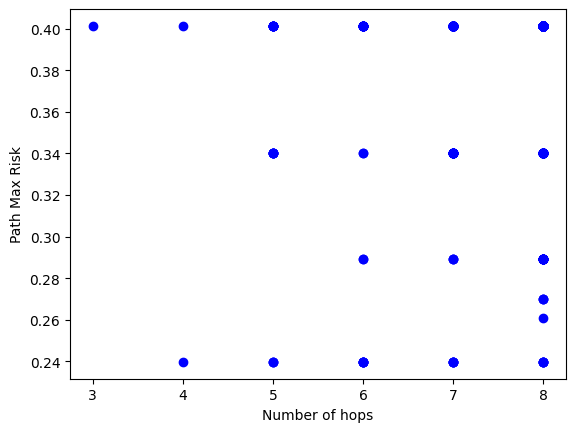

In [24]:


def path_max_risk(path, risk_dict):
    "Return paths risk score as the max risk of the constituent entities"
    risks = [risk_dict[elem] for elem in path]
    return max(risks)

def path_hops(path):
    "Return the number of hops in a path"
    return len(path) - 1

path_risk_measure = lambda path: path_max_risk(path, entity_risks)
path_delay_measure = path_hops

fig, ax = plt.subplots() 
for path in nx.all_simple_paths(g, source, destination, cutoff=max_hops):
    path_risk = path_risk_measure(path)
    path_delay = path_delay_measure(path)
    ax.scatter(path_delay, path_risk, c='b')
ax.set_xlabel("Number of hops")
ax.set_ylabel("Path Max Risk")
plt.title("")


In [25]:
path

[1, 29, 24, 11, 7, 19, 17, 5]

In [26]:
path_delay

7

## Statistics About Simple Safe Routing

In [79]:
import importlib, src, src.nre.safe_routing

importlib.reload(src.nre.safe_routing)
from src.nre.safe_routing import*

In [62]:
res_df = get_safe_routing_perf_stats(g, entity_risks)#, return_idv=False)
res_df

C:\Users\bayer\PycharmProjects\NRE\src\nre\safe_routing.py:109: UserWarning: Multi-safest-paths are not added to variable path!
  warnings.warn('Multi-safest-paths are not added to variable path!')


,Source,Destination,Risk Reduction %,Increase in Hops %
0,0,24,0.000000,0.000000
1,0,9,0.000000,0.000000
2,0,11,0.000000,0.000000
3,0,10,0.000000,0.000000
4,0,23,0.000000,0.000000
...,...,...,...,...
807,29,8,32.784447,66.666667
808,29,15,0.000000,0.000000
809,29,25,0.000000,0.000000
810,29,21,15.277689,33.333333


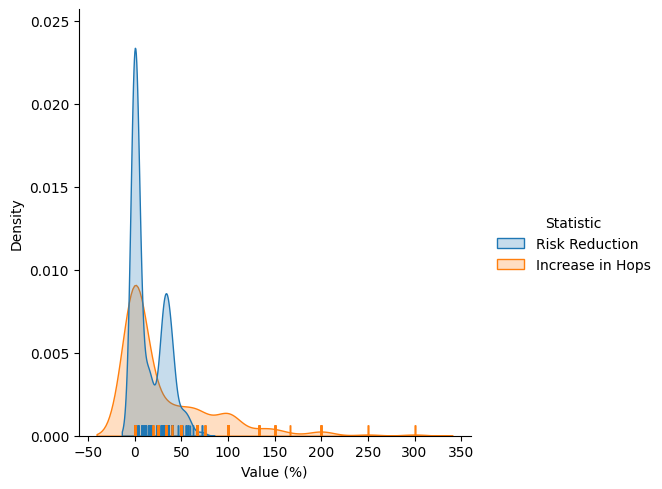

In [66]:

plot_df = pd.DataFrame({'Statistic': 'Risk Reduction', 'Value (%)': res_df['Risk Reduction %']})
plot_df = pd.concat((plot_df, pd.DataFrame({'Statistic': 'Increase in Hops', 'Value (%)': res_df['Increase in Hops %']})), ignore_index=True)

#fig, ax = plt.subplots()
sns.displot(data=plot_df, x="Value (%)", kind="kde", hue='Statistic', fill=True, rug=True)

In [67]:
res_df = get_safe_routing_perf_stats(g, entity_risks, return_idv=False)
res_df

C:\Users\bayer\PycharmProjects\NRE\src\nre\safe_routing.py:109: UserWarning: Multi-safest-paths are not added to variable path!
  warnings.warn('Multi-safest-paths are not added to variable path!')


,Average Risk Reduction %,Average Increase in Hops %
0,14.258422,31.627668


## Monte Carlo over Random Graphs

In [2]:
import importlib, src, src.nre.safe_routing

importlib.reload(src.nre.safe_routing)
from src.nre.safe_routing import*

In [3]:
file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Tuesday-WorkingHours.pcap_ISCX.csv' 
df_cic = pd.read_csv(file_addr, header=0, encoding='cp1252')
df = preprocess_df(df_cic, date_col=' Timestamp')

In [31]:
params = {'c':[1.2], 'p_rewire': [0.2]}
res_df = compare_topologies_simple_safe_routing(params, df=None, n_size=30, n_iter=50, verbose=True) # df

Erdos-Renyi Graphs


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:17<00:00,  2.86it/s]


Barabasi-Albert Graphs


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:19<00:00,  2.54it/s]


Watts-Strogatz Graphs


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:16<00:00,  2.94it/s]


In [36]:
with open(r'saves\safe_routing_mc_30_50.pickle', 'wb') as handle: # sample_nodes.pickle
    pickle.dump(res_df, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [4]:
with open(r'saves\safe_routing_mc_30.pickle', 'rb') as handle:
    res_df = pickle.load(handle) 

In [5]:
res_df

,Source,Destination,Risk Reduction %,Increase in Hops %,Iteration,Graph Model,Parameters
0,0,1,0.000000,0.0,0,Erdos-Renyi,c=1.2
1,0,7,0.000000,0.0,0,Erdos-Renyi,c=1.2
2,0,12,0.000000,0.0,0,Erdos-Renyi,c=1.2
3,0,24,0.000000,0.0,0,Erdos-Renyi,c=1.2
4,0,27,0.000000,0.0,0,Erdos-Renyi,c=1.2
...,...,...,...,...,...,...,...
129341,29,11,5.240092,150.0,49,Watts-Strogatz,"c=1.2, p_rewire=0.2"
129342,29,18,11.966503,20.0,49,Watts-Strogatz,"c=1.2, p_rewire=0.2"
129343,29,17,11.966503,20.0,49,Watts-Strogatz,"c=1.2, p_rewire=0.2"
129344,29,27,0.000000,0.0,49,Watts-Strogatz,"c=1.2, p_rewire=0.2"


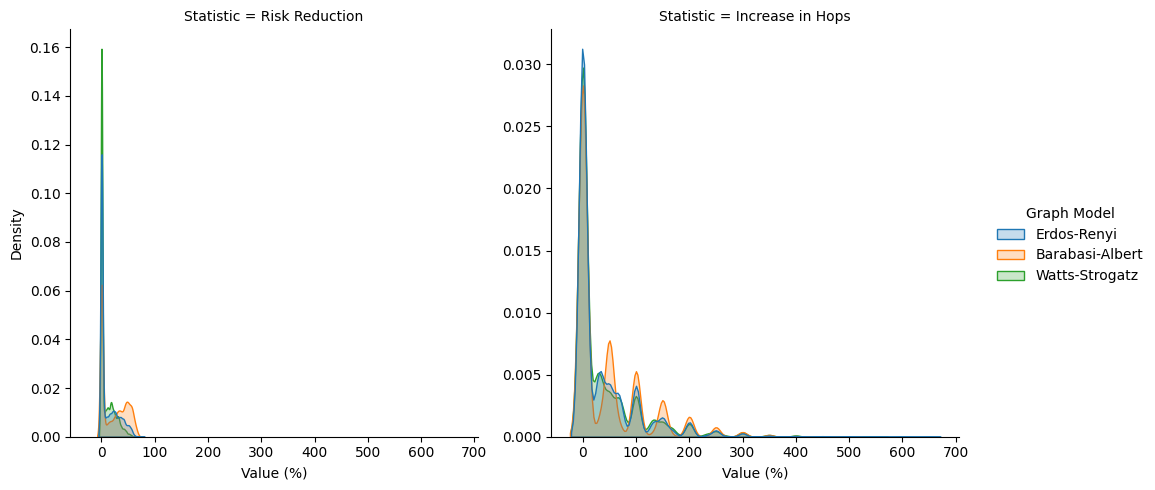

In [6]:
plot_df = pd.DataFrame({'Statistic': 'Risk Reduction', 'Value (%)': res_df['Risk Reduction %'], 'Graph Model': res_df['Graph Model']})
plot_df = pd.concat((plot_df, pd.DataFrame({'Statistic': 'Increase in Hops', 'Value (%)': res_df['Increase in Hops %'], 'Graph Model': res_df['Graph Model']})), ignore_index=True)

#fig, ax = plt.subplots()
#plot_df = plot_df[plot_df['Statistic'] == 'Risk Reduction']
sns.displot(data=plot_df , x="Value (%)", kind="kde", hue='Graph Model', fill=True, rug=False, common_norm=False,
            col='Statistic', facet_kws={'sharey':False})

C:\Users\bayer\AppData\Local\Temp\ipykernel_26112\2245638710.py:8: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  ax = sns.violinplot(data=plot_dff, x='Statistic', y='Value (%)', hue='Graph Model', gap = 0.2, palette=pal, alpha=1)
C:\Users\bayer\AppData\Local\Temp\ipykernel_26112\2245638710.py:15: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  ax = sns.violinplot(data=plot_dff, x='Statistic', y='Value (%)', hue='Graph Model', gap = 0.2, palette=pal, alpha=1)


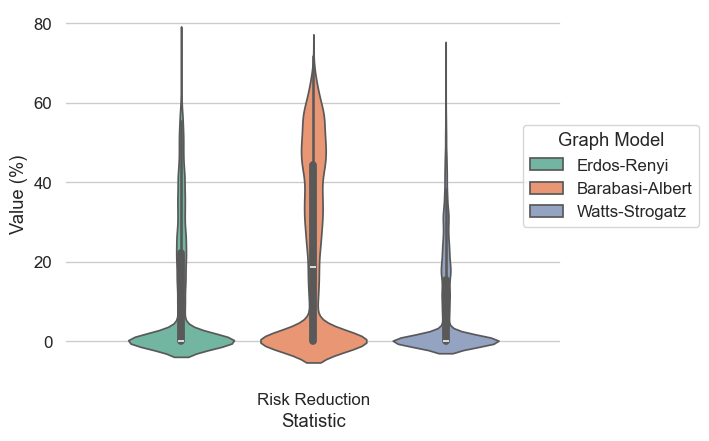

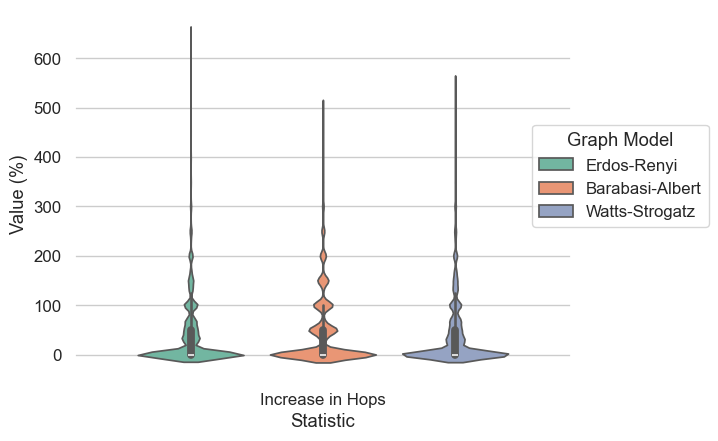

In [7]:
sns.set(font_scale=1.1)
sns.set_style({'axes.facecolor':'white', 'grid.color': '.8'})
#sns.set_style('white')

stt = 'Risk Reduction' # 'Risk Reduction' 'Increase in Hops'
pal = sns.color_palette("Set2")
plot_dff = plot_df[plot_df['Statistic'] == stt]
ax = sns.violinplot(data=plot_dff, x='Statistic', y='Value (%)', hue='Graph Model', gap = 0.2, palette=pal, alpha=1)
sns.move_legend(ax, "center", bbox_to_anchor=(1.1, 0.55))


plt.figure()
stt = 'Increase in Hops'
plot_dff = plot_df[plot_df['Statistic'] == stt]
ax = sns.violinplot(data=plot_dff, x='Statistic', y='Value (%)', hue='Graph Model', gap = 0.2, palette=pal, alpha=1)
#sns.move_legend(ax, "upper left")
sns.move_legend(ax, "center", bbox_to_anchor=(1.1, 0.55))

### Significance

In [8]:
from scipy.stats import ttest_1samp

name = 'Barabasi-Albert'#'Watts-Strogatz'#'Erdos-Renyi'#'Barabasi-Albert'
temp_df = res_df[res_df['Graph Model'] == name]
temp_df

,Source,Destination,Risk Reduction %,Increase in Hops %,Iteration,Graph Model,Parameters
42346,0,1,0.000000,0.0,0,Barabasi-Albert,c=1.2
42347,0,3,0.000000,0.0,0,Barabasi-Albert,c=1.2
42348,0,10,0.000000,0.0,0,Barabasi-Albert,c=1.2
42349,0,19,0.000000,0.0,0,Barabasi-Albert,c=1.2
42350,0,25,0.000000,0.0,0,Barabasi-Albert,c=1.2
...,...,...,...,...,...,...,...
85841,29,2,12.105162,50.0,49,Barabasi-Albert,c=1.2
85842,29,7,0.000000,0.0,49,Barabasi-Albert,c=1.2
85843,29,6,0.000000,50.0,49,Barabasi-Albert,c=1.2
85844,29,0,0.000000,0.0,49,Barabasi-Albert,c=1.2


In [11]:
temp_df.describe()

,Source,Destination,Risk Reduction %,Increase in Hops %,Iteration
count,43500.000000,43500.000000,43500.000000,43500.000000,43500.000000
mean,14.500000,14.500000,22.557972,44.396552,24.500000
std,8.655541,8.655541,22.628982,67.877818,14.431036
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,7.000000,0.000000,0.000000,12.000000
50%,14.500000,14.500000,18.661758,0.000000,24.500000
75%,22.000000,22.000000,44.411792,50.000000,37.000000
max,29.000000,29.000000,71.896460,500.000000,49.000000


In [27]:
stat = 'Increase in Hops %'#'Risk Reduction %'
res = ttest_1samp(temp_df[stat], 0)
print(res), res.pvalue

TtestResult(statistic=136.41621434043196, pvalue=0.0, df=43499)


(None, 0.0)

In [32]:
from scipy.stats import ttest_ind

name1 = 'Barabasi-Albert'#'Watts-Strogatz'#'Erdos-Renyi'#'Barabasi-Albert'
name2 = 'Erdos-Renyi'
stat = 'Risk Reduction %'#'Increase in Hops %'#'Risk Reduction %'


temp_df1 = res_df[res_df['Graph Model'] == name1]
temp_df2 = res_df[res_df['Graph Model'] == name2]
res = ttest_ind(temp_df1[stat], temp_df2[stat])
print(res), res.pvalue

TtestResult(statistic=80.68375500533915, pvalue=0.0, df=85844.0)


(None, 0.0)